In [1]:
# X_{n+1} = e^{−1} X_n+1−e^{−2} ξ_n
import numpy as np
import pandas as pd


def simulate_ou(n_steps, random_state, x0=0.0):
    rng = np.random.default_rng(random_state)
    x = np.empty(n_steps, dtype=float)
    x[0] = float(x0)
    a = np.exp(-1.0)
    b = np.sqrt(1.0 - np.exp(-2.0))
    for t in range(n_steps - 1):
        x[t + 1] = a * x[t] + b * rng.standard_normal()
    return pd.DataFrame({"x": x})


In [2]:
# General gaussian invariant distribution: ξ_n ∼ N(0,1) for OU, not actually used for this figure
# Actual density used is below
def stationary_density(x, theta=1.0, mu=0.0, sigma=1.0):
    var = sigma**2 / (2 * theta)
    return np.exp(-((x - mu) ** 2) / (2 * var)) / np.sqrt(2 * np.pi * var)


In [3]:
# OU specific normalisation constant

from kooplearn._linalg import weighted_norm


def ou_normalisation(functions, x, density):
    #    abs2 = np.abs(functions) ** 2
    #    norms = np.sqrt(np.trapezoid(abs2 * density[:, None], x[:, 0], axis=0))
    W = np.diag(density.reshape(-1))
    norms = weighted_norm(functions, W)
    norms = np.maximum(norms, 1e-12)
    functions = functions / norms
    return functions


In [4]:
# Some reused variables
from kooplearn.preprocessing import FeatureFlattener

n_train_samples = 1000
subsample = 50

x = np.linspace(-4, 4, 1025)[:, None]

flattener = FeatureFlattener()
x_flat = flattener.fit_transform(x)

# This is the exact density used in the paper for OU
density = np.exp(-0.5 * x_flat**2) / np.sqrt(2 * np.pi)


100%|██████████| 10/10 [00:20<00:00,  2.02s/it]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


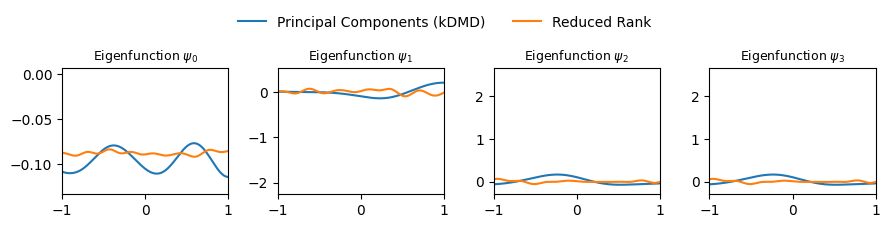

In [5]:
# First, Fig. 2 but with OU

from collections import defaultdict

import matplotlib.pyplot as plt
from tqdm import tqdm

from kooplearn.kernel import KernelRidge


def fit_and_estimate(reduced_rank, x, density, random_state):
    # Substitute Langevin with OU
    data = simulate_ou(
        n_steps=int(7e5),
        random_state=random_state,
        x0=0.0,
    )

    # Sample new trajectories
    data = data.iloc[
        ::subsample  # don't need all data
    ]
    data = data[:n_train_samples]

    # Model definition, same as fig 2 for now
    model = KernelRidge(
        n_components=5,
        reduced_rank=reduced_rank,
        gamma=12.5,
        kernel="rbf",
        alpha=1e-6,
        random_state=random_state,
    )

    # Fit and estimate eigenfunctions
    model.fit(data)  # fit transfer op model
    values, functions = model.eig(
        eval_right_on=x
    )  # (right) eigenvalue estimation, evaluate on array x
    sort_perm = np.flip(np.argsort(np.abs(values)))  # Order decreasingly
    values, functions = values[sort_perm], functions[:, sort_perm]
    functions = ou_normalisation(functions, x, density)
    return functions


# Run functions for both RRR (reduced rank) and kDMD (full rank) estimators
dt = 1e-4
n_repetitions = 10
results = defaultdict(list)
for method, reduced_rank in zip(["Principal Components (kDMD)", "Reduced Rank"], [False, True]):
    for i in tqdm(range(n_repetitions)):
        results[method].append(fit_and_estimate(reduced_rank, x, density, i))

# Print results
fig, axs = plt.subplots(ncols=4, figsize=(9, 2))
for fun_id, ax in enumerate(axs):
    for method, functions in results.items():
        color = "tab:blue" if "Principal" in method else "tab:orange"
        ax.plot(x, functions[0][:, fun_id], color=color, label=method)
    ax.set_title(rf"Eigenfunction $\psi_{fun_id}$", fontsize=9)
    ax.set_xlim(-1, 1)
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncols=2,
    frameon=False,
    bbox_to_anchor=(0.0, 1.05, 1.0, 0.102),
)
plt.tight_layout()
plt.show()


## Figure 1 reproduction
### Kernel family
$$k_{\Pi,\nu}(x,x')=\sum_{i\in\mathbb N}\mu_{\Pi(i)}^{2\nu} f_i(x)f_i(x')$$

ugly-RRR: 100%|██████████| 5/5 [05:30<00:00, 66.19s/it]


('good', 'PCR') (5, 3)
('good', 'RRR') (5, 3)
('bad', 'PCR') (5, 3)
('bad', 'RRR') (5, 3)
('ugly', 'PCR') (5, 3)
('ugly', 'RRR') (5, 3)


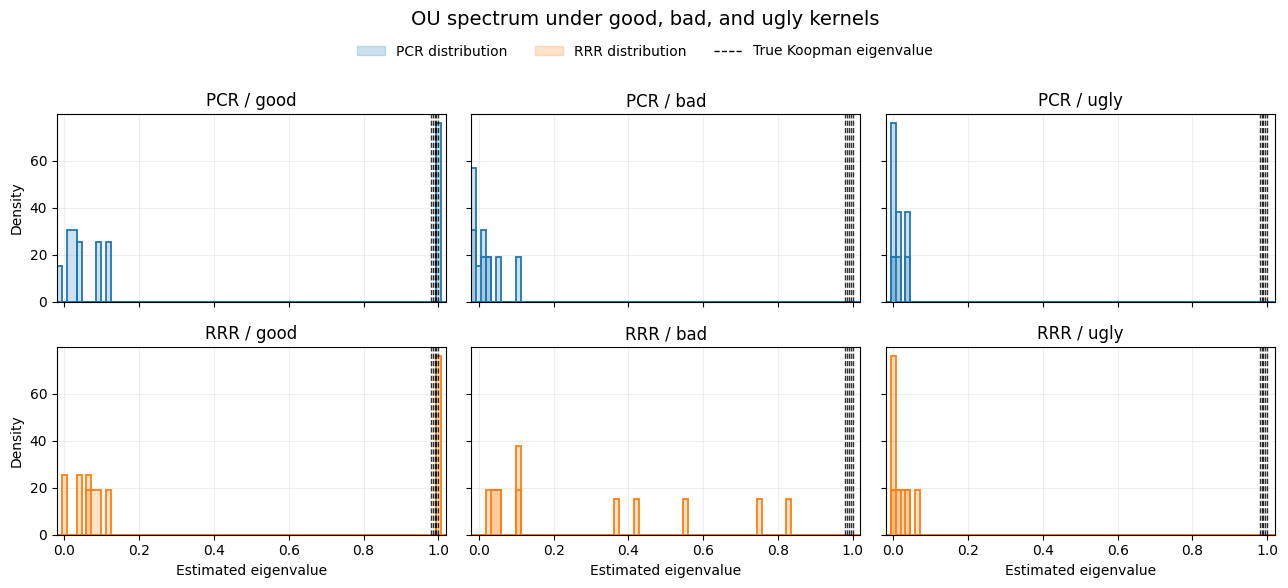

In [24]:
# Spectral rates paper fig. 1-style eigenfunction comparison:
# - 3 columns = good / bad / ugly kernels
# - overlay PCR (blue) and RRR (orange)
# - show mean estimated eigenfunction across trials for the first few modes

from collections import defaultdict
from math import factorial

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from numpy.polynomial.hermite import hermval
from tqdm import tqdm


# ----------------------------------------------------------------------------------------------
# Hermite helpers / kernel family - in line with Kostic et al. Kernel construction in Example 3
# ----------------------------------------------------------------------------------------------
def hermite_prob(n, x):
    c = np.zeros(n + 1)
    c[n] = 1.0
    return hermval(x, c)


def hermite_features(x, M):
    x = np.asarray(x).reshape(-1)
    Phi = np.zeros((x.shape[0], M))
    for j in range(M):
        Phi[:, j] = hermite_prob(j, x) / np.sqrt(factorial(j))
    return Phi


def kernel_permutation(kind, r, M):
    pi = np.arange(M)

    if kind == "good":
        return pi

    if kind == "bad":
        if 2 * r > M:
            raise ValueError(f"Need M >= 2*r for bad kernel, got M={M}, r={r}")
        pi2 = pi.copy()
        a = np.arange(r)
        b = np.arange(r, 2 * r)
        pi2[a] = b[::-1]
        pi2[b] = a[::-1]
        return pi2

    if kind == "ugly":
        return pi[::-1]

    raise ValueError(kind)


def make_weights(kind, r, M):
    mu = np.exp(-np.arange(M))
    nu = 1.0 if kind == "good" else (1.0 / (r**2) if kind == "bad" else r**2)
    pi = kernel_permutation(kind, r, M)
    return mu[pi] ** (2.0 * nu)


def hermite_kernel(kind, r, M):
    w = make_weights(kind, r, M)

    def kernel(x, y):
        x = np.asarray(x).ravel()
        y = np.asarray(y).ravel()
        sx = 0.0
        for m in range(M):
            fx = hermite_prob(m, x[0]) / np.sqrt(factorial(m))
            fy = hermite_prob(m, y[0]) / np.sqrt(factorial(m))
            sx += w[m] * fx * fy
        return float(sx)

    return kernel


# -----------------------------
# OU reference eigenfunctions
# -----------------------------
def compute_ou_eig(gamma, lag, num_components):
    n = np.arange(num_components)
    return np.exp(-n * gamma * lag)


# -----------------------------
# Sign-align estimated functions to a reference
# -----------------------------
def standardize_sign(eigenfunction, reference, x):
    eigenfunction_cut = cut_functions_to_domain(eigenfunction, x)
    reference_cut = cut_functions_to_domain(reference, x)
    norm_p = np.linalg.norm(eigenfunction_cut + reference_cut)
    norm_m = np.linalg.norm(eigenfunction_cut - reference_cut)
    if norm_p <= norm_m:
        return -1.0 * eigenfunction
    else:
        return eigenfunction


def cut_functions_to_domain(functions, x, x_lims=(-1, 1)):
    mask = (x >= x_lims[0]) & (x <= x_lims[1])
    return functions[mask]


# -----------------------------
# Parameters
# -----------------------------
kernels = ["good", "bad", "ugly"]
methods = [("PCR", False), ("RRR", True)]

n_trials = 5  # increase toward paper settings for smoother curves
n_show = 3  # number of leading eigenfunctions to plot
M = 10  # kernel truncation level
r = n_show
gamma = 1.0
dt = 1e-4
subsample = 50
lag = dt * subsample  # now consistent with how `data` was actually generated
n_components = 5
true_eigs = compute_ou_eig(gamma, lag, n_components)

x_plot = x.reshape(-1)
true_funcs = compute_ou_eig(gamma, lag, n_components)

results = defaultdict(list)


# -----------------------------
# Fit model and return eigenvalues
# -----------------------------
def fit_and_estimate_values(reduced_rank, x, density, random_state, kind, r, M, n_show):
    out = np.full(n_show, np.nan, dtype=float)

    try:
        data = simulate_ou(n_steps=20000, random_state=random_state)
        data = data.iloc[::subsample]
        data = data[:n_train_samples]

        model = KernelRidge(
            n_components=n_show,
            reduced_rank=reduced_rank,
            kernel=hermite_kernel(kind, r, M),
            alpha=1e-8,
            random_state=random_state,
        )

        model.fit(data)
        values, functions = model.eig(eval_right_on=x)

        values = np.asarray(values)
        values = np.real_if_close(values)
        values = np.real(values)
        if values.ndim == 0:
            values = np.array([float(values)])
        sort_perm = np.flip(np.argsort(np.abs(values)))
        values = values[sort_perm]

        k = min(n_show, len(values))
        out[:k] = values[:k]

    except Exception:
        pass

    return out


# -----------------------------
# Collect spectra
# -----------------------------
results = defaultdict(list)

for kind in kernels:
    for method, reduced_rank in methods:
        for trial in tqdm(range(n_trials), desc=f"{kind}-{method}"):
            vals = fit_and_estimate_values(
                reduced_rank=reduced_rank,
                x=x,
                density=density,
                random_state=trial,
                kind=kind,
                r=r,
                M=M,
                n_show=n_show,
            )
            results[(kind, method)].append(vals)

for key in results:
    results[key] = np.asarray(results[key], dtype=float)
    print(key, results[key].shape)

# -----------------------------
# Plot
# -----------------------------
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13.0, 5.5),
    sharex=True,
    sharey=True,
)

colors = {"PCR": "tab:blue", "RRR": "tab:orange"}
bins = np.linspace(-0.02, 1.02, 80)

for row, (method, _) in enumerate(methods):
    for col, kind in enumerate(kernels):
        ax = axs[row, col]
        vals = results[(kind, method)]  # (n_trials, n_show)

        # plot empirical distributions mode-by-mode
        for m in range(n_show):
            vm = vals[:, m]
            vm = vm[np.isfinite(vm)]

            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="stepfilled",
                alpha=0.22,
                color=colors[method],
            )

            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="step",
                lw=1.3,
                color=colors[method],
            )

        # true Koopman eigenvalue lines
        for ev in true_eigs:
            ax.axvline(ev, color="black", ls="--", lw=1.0, alpha=0.8)

        ax.set_title(f"{method} / {kind}", fontsize=12)
        ax.set_xlim(-0.02, 1.02)
        ax.grid(alpha=0.20)

        if col == 0:
            ax.set_ylabel("Density")

for ax in axs[-1, :]:
    ax.set_xlabel("Estimated eigenvalue")

# compact legend

legend_handles = [
    Patch(facecolor="tab:blue", edgecolor="tab:blue", alpha=0.22, label="PCR distribution"),
    Patch(facecolor="tab:orange", edgecolor="tab:orange", alpha=0.22, label="RRR distribution"),
    Line2D([0], [0], color="black", lw=1.0, ls="--", label="True Koopman eigenvalue"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "OU spectrum under good, bad, and ugly kernels",
    fontsize=14,
    y=1.06,
)

plt.tight_layout()
plt.show()


In [21]:
from kooplearn._utils import stable_topk

n_trials = 5
results = defaultdict(list)

for kind in kernels:
    for method, reduced_rank in methods:
        for trial in tqdm(range(n_trials), desc=f"{kind}-{method}"):
            tmp = np.full(n_show, np.nan, dtype=float)

            try:
                values = fit_and_estimate_values(
                    reduced_rank=reduced_rank,
                    x=x,
                    density=density,
                    random_state=trial,
                    kind=kind,
                    r=n_show,
                )

                values = np.asarray(values)
                values = np.real_if_close(values)
                values = np.real(values)

                vals, idx = stable_topk(values, k_max=n_show)
                vals = np.asarray(vals).ravel()
                vals = np.real_if_close(vals)
                vals = np.real(vals)

                k = min(n_show, vals.size)
                tmp[:k] = np.abs(vals[:k])

            except Exception:
                pass

            results[(kind, method)].append(tmp)

for key in results:
    arr = np.asarray(results[key], dtype=float)
    print(key, arr.shape, arr.dtype)
    results[key] = arr

vals = np.asarray(results[(kind, method)], dtype=float)
if vals.ndim == 1:
    vals = vals.reshape(1, -1)

n_plot = min(n_show, vals.shape[1])


ugly-RRR: 100%|██████████| 5/5 [00:00<00:00, 53227.21it/s]

('good', 'PCR') (5, 3) float64
('good', 'RRR') (5, 3) float64
('bad', 'PCR') (5, 3) float64
('bad', 'RRR') (5, 3) float64
('ugly', 'PCR') (5, 3) float64
('ugly', 'RRR') (5, 3) float64


In [ ]:
# Spectral rates paper fig. 1-style eigenfunction comparison:
# - 3 columns = good / bad / ugly kernels
# - overlay PCR (blue) and RRR (orange)
# - show mean estimated eigenfunction across trials for the first few modes

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from tqdm import tqdm

# -----------------------------
# Parameters
# -----------------------------
kernels = ["good", "bad", "ugly"]
methods = [("PCR", False), ("RRR", True)]

n_trials = 50  # increase toward paper settings for smoother curves
n_show = 3  # number of leading eigenfunctions to plot
M = 10  # kernel truncation level
r = n_show
gamma = 1.0
dt = 1e-4
subsample = 50
lag = dt * subsample  # now consistent with how `data` was actually generated
n_components = 5
true_eigs = compute_ou_eig(gamma, lag, n_show)

x_plot = x.reshape(-1)

results = defaultdict(list)


# -----------------------------
# Fit model and return eigenvalues
# -----------------------------
def fit_and_estimate_values(reduced_rank, x, density, random_state, kind, r, M, n_show):
    out = np.full(n_show, np.nan, dtype=float)

    try:
        data = simulate_ou(n_steps=20000, random_state=random_state)
        data = data.iloc[::subsample]
        data = data[:n_train_samples]

        model = KernelRidge(
            n_components=n_show,
            reduced_rank=reduced_rank,
            kernel=hermite_kernel(kind, r, M),
            alpha=1e-8,
            random_state=random_state,
        )

        model.fit(data)
        values, functions = model.eig(eval_right_on=x)

        values = np.asarray(values)
        values = np.real_if_close(values)

        if values.ndim == 0:
            values = np.array([values])

        # keep only approximately real eigenvalues
        real_mask = np.abs(np.imag(values)) < 1e-8
        values = np.real(values[real_mask])

        # keep only finite values
        values = values[np.isfinite(values)]

        # exclude values slightly above 1 from numerical noise
        values = values[values <= 1.0 + 1e-8]

        # sort by value, largest first
        values = np.sort(values)[::-1]

        k = min(n_show, values.size)
        out[:k] = values[:k]

    except Exception:
        pass

    return out


# -----------------------------
# Collect spectra
# -----------------------------
results = defaultdict(list)

for kind in kernels:
    for method, reduced_rank in methods:
        for trial in tqdm(range(n_trials), desc=f"{kind}-{method}"):
            vals = fit_and_estimate_values(
                reduced_rank=reduced_rank,
                x=x,
                density=density,
                random_state=trial,
                kind=kind,
                r=r,
                M=M,
                n_show=n_show,
            )
            results[(kind, method)].append(vals)

for key, arr in results.items():
    print(key, np.nanmean(arr, axis=0))
# -----------------------------
# Plot
# -----------------------------
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13.0, 5.5),
    sharex=True,
    sharey=True,
)

colors = {"PCR": "tab:blue", "RRR": "tab:orange"}
bins = np.linspace(-0.02, 1.02, 80)

for row, (method, _) in enumerate(methods):
    for col, kind in enumerate(kernels):
        ax = axs[row, col]
        vals = results[(kind, method)]  # (n_trials, n_show)

        # plot empirical distributions mode-by-mode
        for m in range(n_show):
            vm = vals[:, m]
            vm = vm[np.isfinite(vm)]

            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="stepfilled",
                alpha=0.22,
                color=colors[method],
            )

            ax.hist(
                vm,
                bins=bins,
                density=True,
                histtype="step",
                lw=1.3,
                color=colors[method],
            )

        # true Koopman eigenvalue lines
        for ev in true_eigs:
            ax.axvline(float(ev), color="black", ls="--", lw=1.0, alpha=0.8)

        ax.set_title(f"{method} / {kind}", fontsize=12)
        ax.set_xlim(-0.02, 1.02)
        ax.grid(alpha=0.20)

        if col == 0:
            ax.set_ylabel("Density")

for ax in axs[-1, :]:
    ax.set_xlabel("Estimated eigenvalue")

# compact legend

legend_handles = [
    Patch(facecolor="tab:blue", edgecolor="tab:blue", alpha=0.22, label="PCR distribution"),
    Patch(facecolor="tab:orange", edgecolor="tab:orange", alpha=0.22, label="RRR distribution"),
    Line2D([0], [0], color="black", lw=1.0, ls="--", label="True Koopman eigenvalue"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "OU spectrum under good, bad, and ugly kernels",
    fontsize=14,
    y=1.06,
)

plt.tight_layout()
plt.show()


good-RRR:  90%|█████████ | 45/50 [10:34:05<8:18:37, 5983.43s/it]